# Final Project 


<br>
<br>


___

# Analysis of factors contributing to bike rentals


### Overview:


* **Name**:  Sileas Kazuma Hugot
* **Student number**: B990372166

<br>

### Purpose:

* The purpose of this project is to determine the weather factors that lead to bike rentals in Seoul, Korea
* The key dependent variable is the "Rentend Bike Count" an integer.
* The key independent variable are:
    * Date
    * Hour
    * Temperature
    * Humidity
    * Windspeed
    * Visibility
    * Dew point temperature
    * Solar radiation
    * Rainfall
    * Snowfall
    * Seasons
    * Whether it is a holiday
    * Whether it is a functional day
* It has 8760 instances (different hours and dates measurements) there are no missing values for the instances.


<br>

### Dataset source:
The data come from the [Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand) dataset from the [UCI Machine Learning repository](https://archive.ics.uci.edu/ml/index.php):

Available for download [here](https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip)

#### Reference:
Sathishkumar V E, Jangwoo Park, Yongyun Cho, "Using data mining techniques for bike sharing demand prediction in Metropolitan city", Computer Communications, vol. 153, pp. 353-366, 2020. Sathishkumar V E, Yongyun Cho, "A rule-based model for Seoul Bike sharing demand prediction using Weather data", European Journal of Remote Sensing, Vol. 52, no. 1, pp. 166-183, 2020.

<br>
<br>
<br>
<br>

___

## Descriptive Statistics

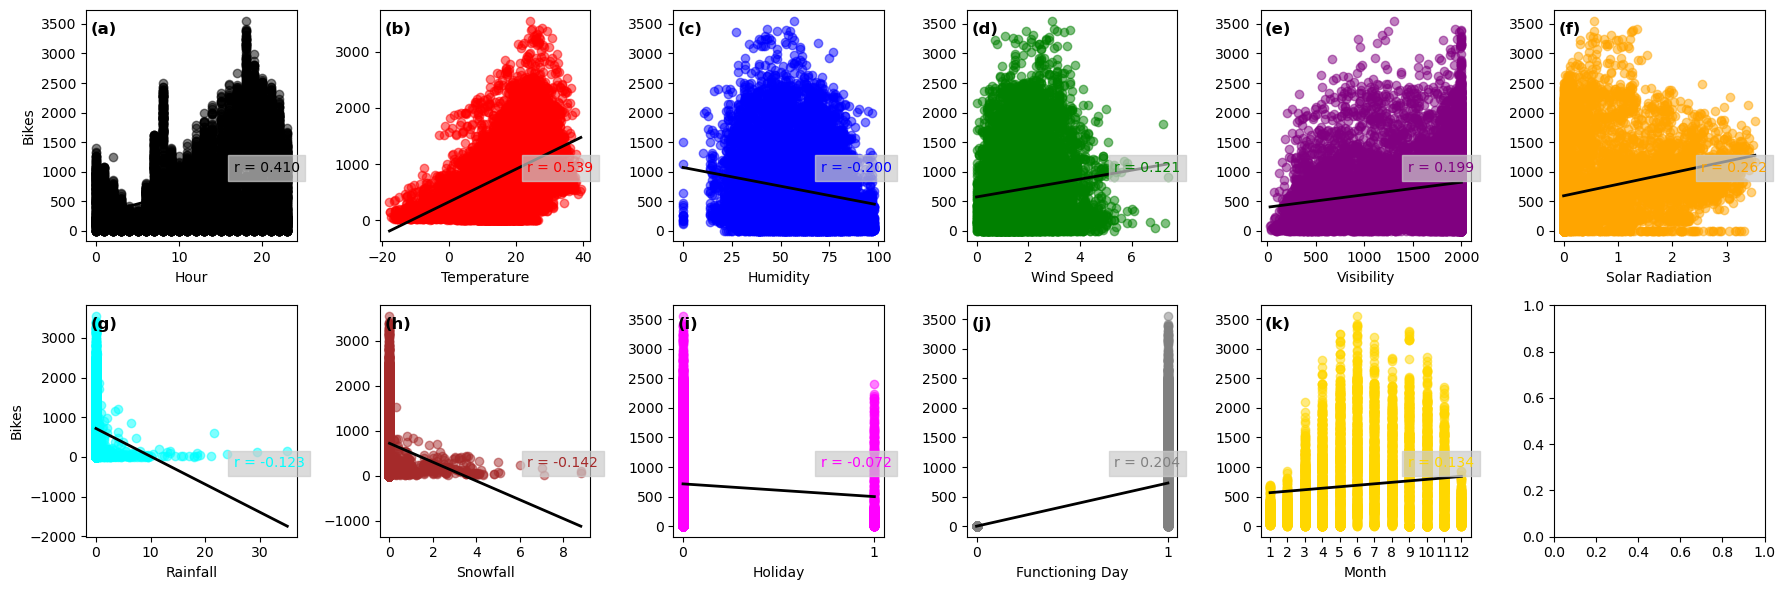

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

In [1]:
from descriptive import *

In [2]:
display_central_tendency_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Central tendency summary statistics.</span></p>

,Bike Count,Hour,Temperature,Humidity,Wind Speed,Visibility,Solar Radiation,Rainfall,Snowfall,Holiday,Functioning Day,Month
mean,704.602055,11.5,12.882922,58.226256,1.724909,1436.825799,0.569111,0.148687,0.075068,0.049315,0.966324,6.526027
median,504.500000,11.5,13.700000,57.000000,1.500000,1698.000000,0.010000,0.000000,0.000000,0.000000,1.000000,7.000000
mode,0.000000,0.0,19.100000,53.000000,1.100000,2000.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000


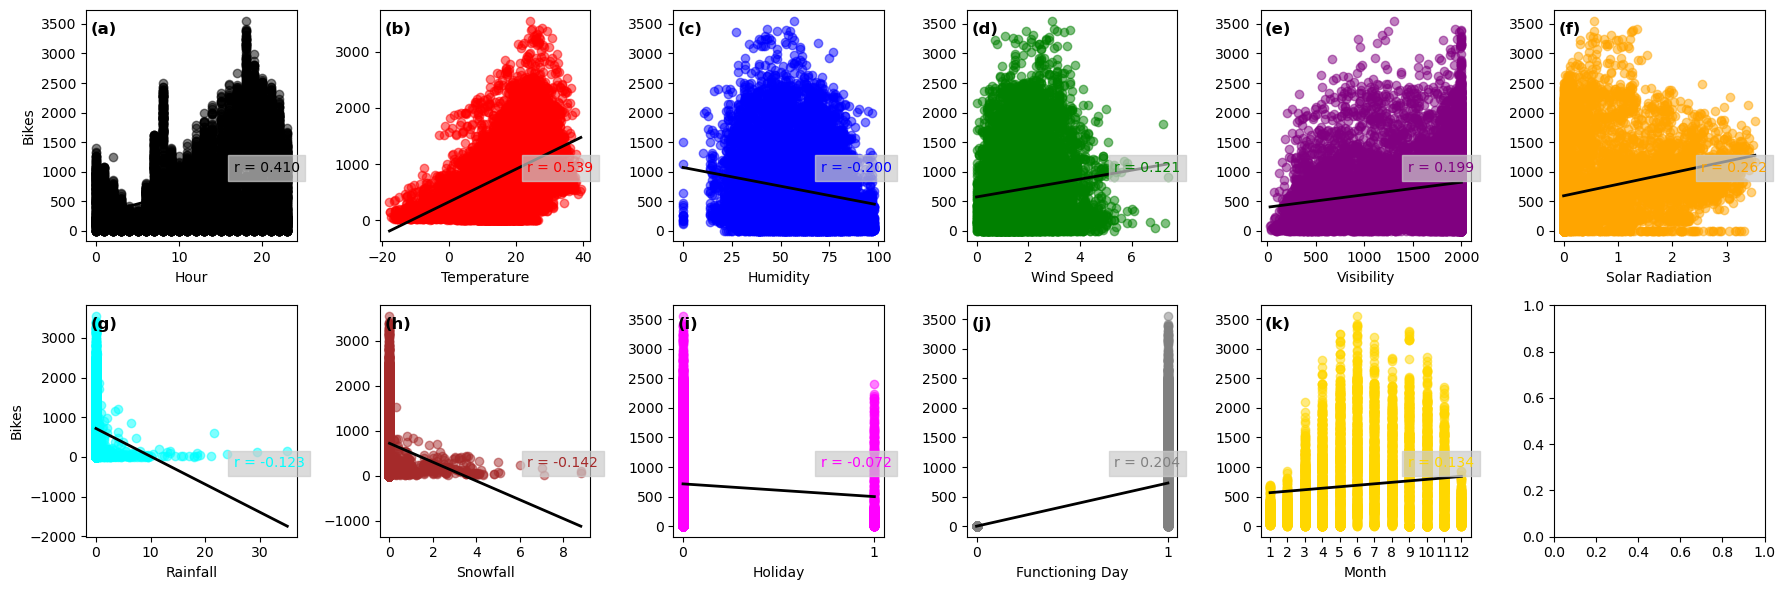

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

In [3]:
plot_descriptive()

___

## Hypothesis Testing



In [4]:
import classical as an

### Analysis 1:
We test whether the average number of rented bikes differs on holidays vs non-holiday days using two-sample t-test.

H0: Mean bike rentals are the same on holidays and non-holidays.

H1: The means differ.

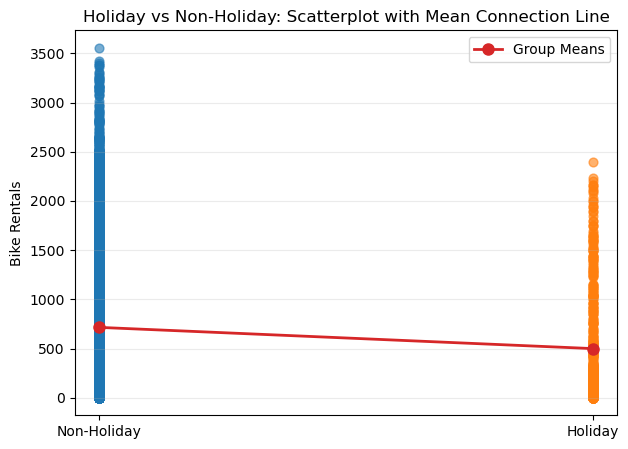

t value:  -6.7874340454159166
p value:  1.2156443235024855e-11


In [5]:
t, p = an.analysis1()
print("t value: ", t)
print("p value: ",p)


**Fig.2:** Comparison of bike rental counts on holidays and non-holidays.
Points represent daily observations, with horizontal lines indicating group means.
The associated t-test evaluates whether mean rentals differ significantly between the two groups.


The test returned t = -6.79 and p = 1.22
Since p < 0.05, H0 is rejected meaning holidays significantly change the number of rented bikes.
Sine t is negative the average number of bike rentals on holidays is lower than non-holidays.
A possible explanation is the influence of bike usage for commuting

We can try to look into this non commuting usage a bit further in analysis 2.
We will look at the temperature and see if it affects bike rentals in different periods of the day.

### Analysis 2
We study how temperature affects under interesting points between four time-of-day groups (Day, Evening, Morning, LateNight) with 23-5 being LateNight, 5-10 being Morning, 10-16 being Day, 16-23 being Evening

From the first graph we can find interesting behaviour at around the 30% of warmest temperature. 
We then restricted the analysis on the 30% warmest hours.


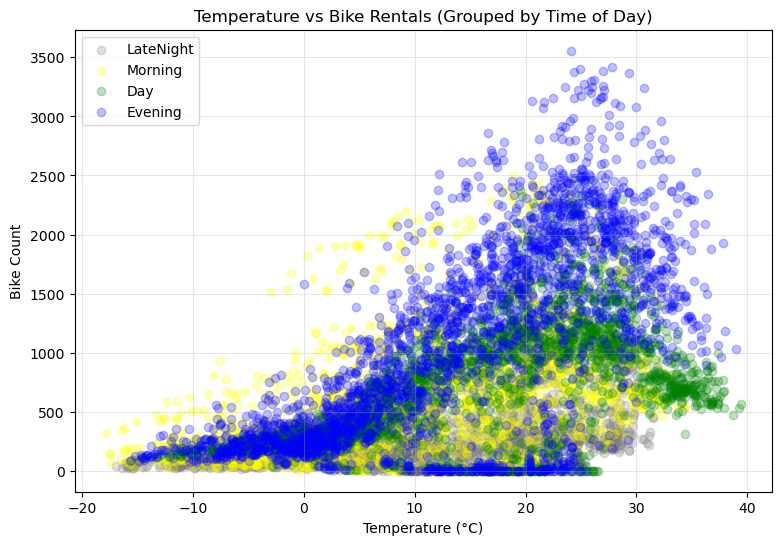

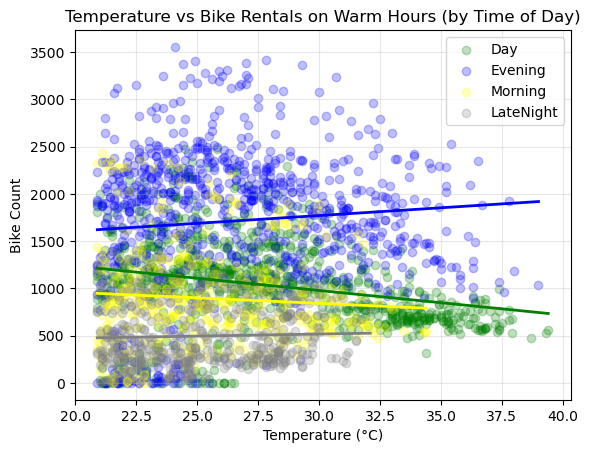

{'Day': (1.2538573341930157e-13, -25.892163322592246), 'Evening': (0.008348637426829482, 16.454981090103228), 'Morning': (0.1109913103664327, -11.622629913559257), 'LateNight': (0.3774741096732096, 4.359787357547276)}
F_onewayResult(statistic=551.2741136366833, pvalue=4.537974831601656e-278)


In [16]:
rLR, rAOVA = an.analysis2()
print(rLR)
print(rAOVA)

**Fig.3:** Relationship between temperature and bike rentals during warm conditions,
separated by time-of-day categories. Linear trends illustrate how temperature sensitivity
varies across different periods, supporting the subsequent ANOVA results.


The regression slopes differed between the categories. 

During the day temperatures have a stong effect on bike rentals with a slope at aorund -25.89 and a very small pvalue way below 0.05, meaning that as temperatures rise to higher levels, daytime biking rentals decreases.

During the morning and late night p values are way beyond 0.05

During the evening temperatures have a significant effect on bike rentals with a slope at around 16.45 and a small pvalue below 0.05, meaning that as temperatures rise to higher levels, evening time biking rentals increases.

A one-way ANOVA on bike counts across the four groups returns F = 551.27 with a very small p value below 0.05, indicating that time-of-day groups differ significantly in rental levels under warm conditions.

This analysis shows that temperature does not influence bike demand equaly. Heat decreases daytime biking rentals but increases evening biking rentals at high temperature hours.

___

## Machine learning



In [7]:
import machine as mc

### Result 1: Bike Rental Demand Prediction using supervised learning
We compare KN-regression and SVR. The feature set are time and weather variables (Hour, Temperature, Humidity, Wind Speed, Visibility, Solar Radiation, and Rainfall) and the target variable was the Bike Count.
75% of the dataset was used for training and 25% for testing. The features are standardized with StandardScaler. Performance was valued using RMSE and R^2. After testing KNN was found to be more accurate:

KNN Regression
k = 10
RMSE = 359.0997665124727
R^2  = 0.6848672226962234


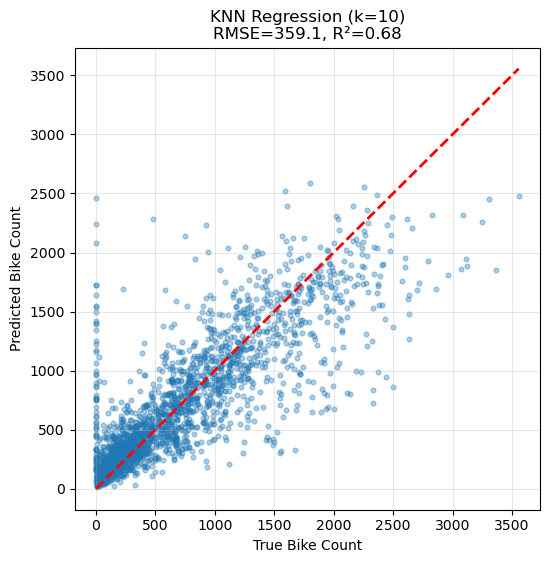

In [12]:
KNN_reggg = mc.KN_reg_result()

**Fig.4:** Predicted versus observed bike rental counts for KNN regression.
Points close to the diagonal indicate accurate predictions, while deviations highlight
model error, particularly at extreme rental values.


Results:
KN regression showed an RMSE of 359.1 and an R^2 of 0.631.
SVR achieved an RMSE of 388.3 and an R^2 of 0.685.
The predicted against true scatter plot show that KN prediction lie closer to the line than SVR prediction indicating higher accuracy.

Interpretation:
KN achieving a preciser prediction could indicate that the patterns for bike rental demand is motivated from local patterns such as specific combinations of hour and weather conditions. Because KN predicts demand based on nearby observation whereas SVR tries to fit a global funcion.

### Result 2: Identifying patterns with PCA
We use unsuppervised learning using PCA and K-means clustering.
PCA to first reduce the dimensionality into 2 component to have a readable graph. We also look at the proportion of variance to see how representativbe the reduced space is. Then K-means clustering was performed in the PCA space. To decide the number of clusters we used the elbow method and to evaluate the clustering we use the silhouette score.

Explained variance ratio: [0.31605725 0.18718075]
Total explained variance: 0.503238002586298


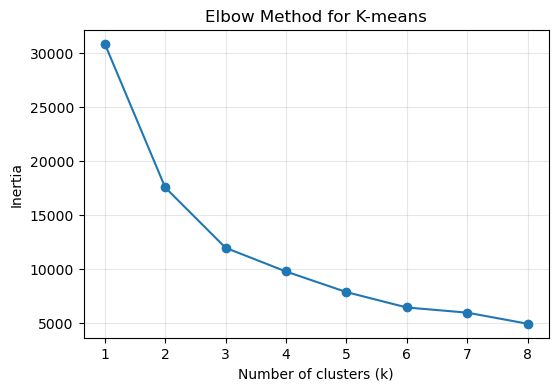

Silhouette score for K=3:  0.38562899602895745


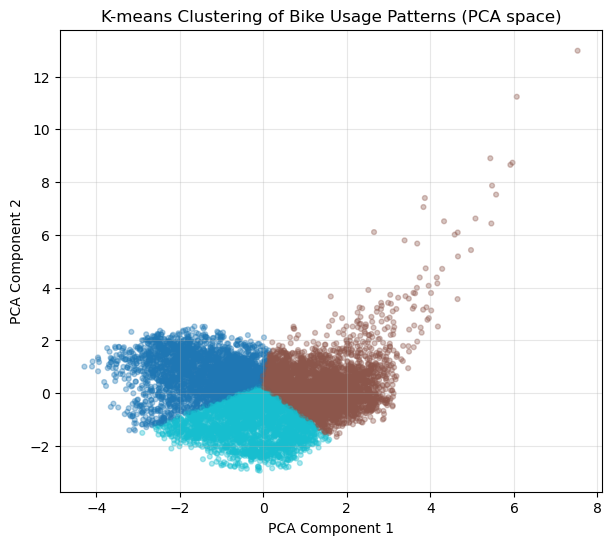

In [9]:
sil_score, PCA_res = mc.PCA_result()

**Fig.5:** Two-dimensional PCA projection of the dataset with K-means cluster assignments.
Clusters represent distinct usage patterns characterized by differing rental levels
and environmental conditions.


The explained variance from the dimension reduction is reasonable making this direction of 2D analysis seen reasonable. The elbow plot shows that at k=3 there is a clear bend indicating that 3 cluster is a good choice. Our silhouette score of 0.386 meaning a reasonable and meaningful structure. We can now try to interpret the different clusters from the graph. To do so we can look at the characteristic values of the mean value in each cluster:

In [10]:
print(PCA_res) 

          Bike Count  Temperature       Hour   Humidity  Rainfall
Cluster                                                          
0        1196.069759    21.731317  15.056030  45.497959  0.003043
1         520.670743    14.354489   9.090665  77.715777  0.385506
2         443.619838     2.270612  10.945059  46.778761  0.000627


Looking at the mean value we can interpret the following clusters:
- Cluster 0: High-demand, warm, afternoon usage, low humidity and rainfall
- Cluster 1: Low demand, mild temperatures, morning usage, high humidity and rainfall
- Cluster 2: Low demand, cold temperatures, morning-noon usage, low humidity and rainfall

___

## Summary

- Fig.1 and Table 1 show that bike rentals are strongly associated with hour of day and temperature.
- Fig.2 indicates a statistically significant difference in rentals between holidays and non-holidays.
- Fig.3 demonstrates that temperature effects depend on time of day during warm conditions.
- Fig.4 shows that the selected regression model predicts mid-range rentals accurately.
- Fig.5 reveals distinct usage regimes captured by unsupervised clustering.
